# Assignment - 9
# Image Classification using Convolutional Neural Networks (CNN)

In [47]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

from sklearn.metrics import confusion_matrix, classification_report

# TASK 1 : Data Understanding

In [48]:
dataset_path = "PetImages"

In [49]:
for folder in os.listdir(dataset_path):
    print(folder)

    folder_path = os.path.join(dataset_path, folder)

    for image in os.listdir(folder_path)[:5]:
        print("   ", image)

Cat
    0.jpg
    1.jpg
    10.jpg
    100.jpg
    1000.jpg
Dog
    0.jpg
    1.jpg
    10.jpg
    100.jpg
    1000.jpg


In [50]:
classes = os.listdir(dataset_path)

print("Classes:", classes)
print("Number of Classes:", len(classes))

Classes: ['Cat', 'Dog']
Number of Classes: 2


In [51]:
total_images = 0

for folder in classes:

    folder_path = os.path.join(dataset_path, folder)

    count = len(os.listdir(folder_path))

    print(folder, "=", count)

    total_images += count

print("Total Images =", total_images)

Cat = 12499
Dog = 12499
Total Images = 24998


In [52]:
first_class = classes[0]

first_image = os.listdir(os.path.join(dataset_path, first_class))[0]

image_path = os.path.join(dataset_path, first_class, first_image)

img = Image.open(image_path)

print("Image Size:", img.size)

Image Size: (500, 375)


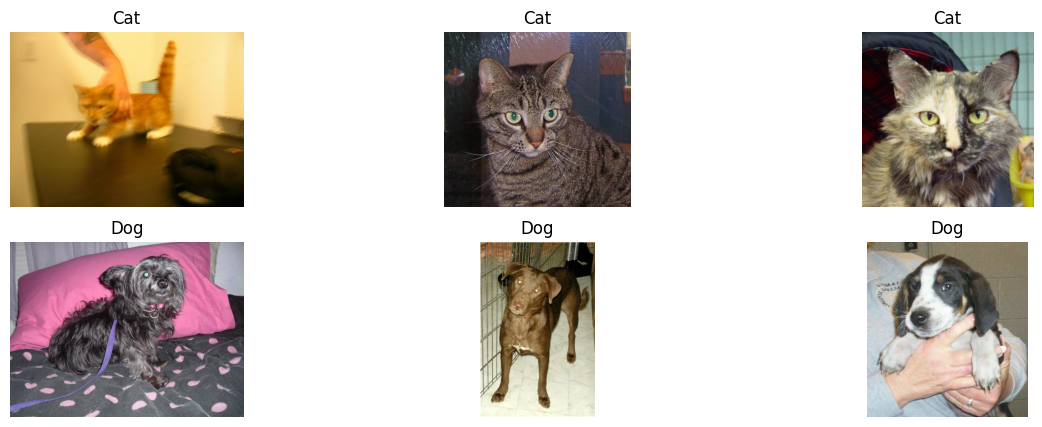

In [53]:
plt.figure(figsize=(15,5))

count = 1

for folder in classes:

    folder_path = os.path.join(dataset_path, folder)

    images = os.listdir(folder_path)

    for image in images[:3]:

        image_path = os.path.join(folder_path, image)

        img = Image.open(image_path)

        plt.subplot(2,3,count)
        plt.imshow(img)
        plt.title(folder)
        plt.axis("off")

        count += 1

plt.show()

# TASK 2: Data Preprocessing

In [54]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [55]:
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

Found 20000 images belonging to 2 classes.


In [56]:
test_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 4998 images belonging to 2 classes.


In [57]:
print(train_generator.class_indices)

{'Cat': 0, 'Dog': 1}


In [58]:
print("Training Images:", train_generator.samples)

Training Images: 20000


In [59]:
print("Testing Images:", test_generator.samples)

Testing Images: 4998


In [60]:
images, labels = next(train_generator)

print("Image Batch Shape:", images.shape)
print("Label Batch Shape:", labels.shape)

Image Batch Shape: (32, 128, 128, 3)
Label Batch Shape: (32,)


# TASK 3 : Model Development

In [61]:
model = Sequential()

model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        input_shape=(128,128,3)
    )
)

c:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
model.add(MaxPooling2D(pool_size=(2,2)))

In [63]:
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu"
    )
)

In [64]:
model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [65]:
model.add(
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation="relu"
    )
)

In [66]:
model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [67]:
model.add(
    Flatten()
)

In [68]:
model.add(
    Dense(
        units=128,
        activation="relu"
    )
)

In [69]:
model.add(
    Dense(
        units=1,
        activation="sigmoid"
    )
)

In [70]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [72]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

Epoch 1/10
177/625 ━━━━━━━━━━━━━━━━━━━━ 2:47 373ms/step - accuracy: 0.5287 - loss: 0.7258

c:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 244s 386ms/step - accuracy: 0.6461 - loss: 0.6154 - val_accuracy: 0.7217 - val_loss: 0.5450
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 249s 399ms/step - accuracy: 0.7690 - loss: 0.4803 - val_accuracy: 0.7755 - val_loss: 0.4773
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 252s 403ms/step - accuracy: 0.8209 - loss: 0.3984 - val_accuracy: 0.8207 - val_loss: 0.3907
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 280s 448ms/step - accuracy: 0.8533 - loss: 0.3327 - val_accuracy: 0.8367 - val_loss: 0.3791
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 266s 425ms/step - accuracy: 0.8860 - loss: 0.2659 - val_accuracy: 0.8343 - val_loss: 0.3884
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 319s 510ms/step - accuracy: 0.9205 - loss: 0.1958 - val_accuracy: 0.8331 - val_loss: 0.4458
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 245s 391ms/step - accuracy: 0.9516 - loss: 0.1230 - val_accuracy: 0.8303 - val_loss: 0.5460
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 274s 439ms/step - accuracy: 0.9729 - loss: 0.07

# TASK 4 : Model Evaluation

In [73]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.8203 - loss: 0.8598
Test Loss: 0.8598002791404724
Test Accuracy: 0.8203281164169312


In [74]:
test_generator.reset()

predictions = model.predict(test_generator)

predictions = (predictions > 0.5).astype(int)

157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step


In [75]:
true_labels = test_generator.classes

In [76]:
print(classification_report(true_labels, predictions))

              precision    recall  f1-score   support

           0       0.84      0.79      0.81      2499
           1       0.80      0.85      0.83      2499

    accuracy                           0.82      4998
   macro avg       0.82      0.82      0.82      4998
weighted avg       0.82      0.82      0.82      4998



In [77]:
cm = confusion_matrix(true_labels, predictions)

print(cm)

[[1975  524]
 [ 374 2125]]


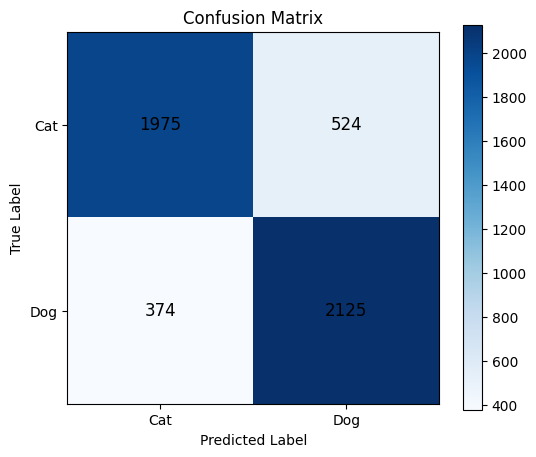

In [80]:
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6,5))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.colorbar()

classes = ["Cat", "Dog"]

plt.xticks([0,1], classes)
plt.yticks([0,1], classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Display values inside the boxes
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="black",
                 fontsize=12)

plt.show()

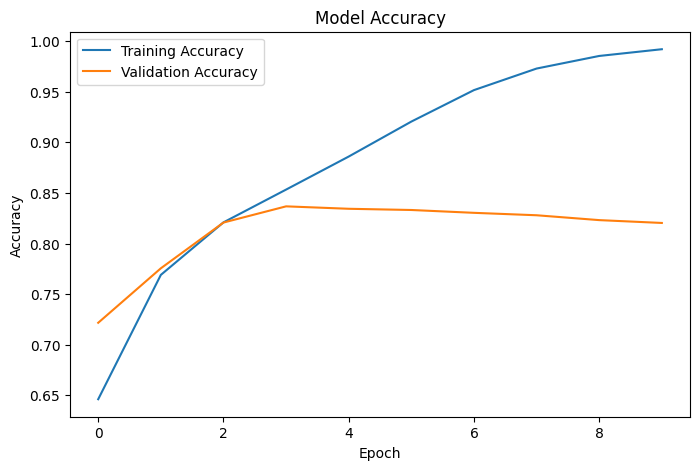

In [78]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

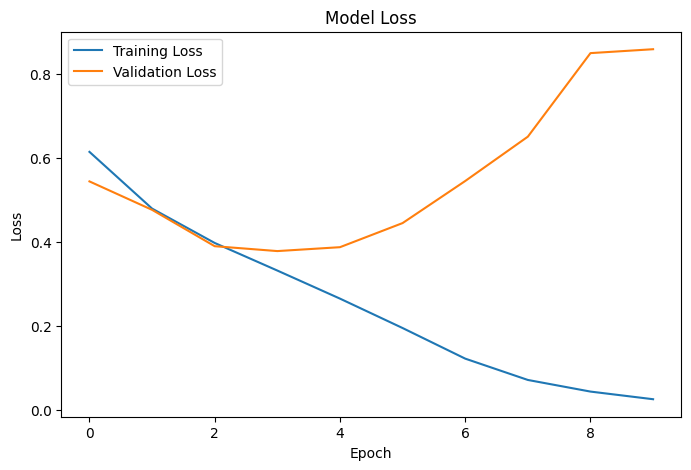

In [79]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

## Observations

1. The training accuracy increased steadily from the first epoch to the tenth epoch.
2. The validation accuracy reached approximately 81%, showing that the model learned useful features for classifying cats and dogs.
3. The training loss decreased with each epoch, indicating successful learning.
4. The confusion matrix and classification report show that the CNN can classify most images correctly, though a few are still misclassified.

# Task 5: Conclusion

In this assignment, a Convolutional Neural Network (CNN) was successfully developed to classify images of cats and dogs. The model was trained using the Cats vs Dogs dataset and achieved good accuracy, showing that CNNs are effective for image classification tasks. Convolution layers helped the model identify important features such as edges, shapes, and textures, while max-pooling layers reduced the image size and improved training efficiency. Compared to a traditional Artificial Neural Network (ANN), a CNN automatically extracts image features, making it more accurate and suitable for computer vision tasks. However, one limitation of CNNs is that they require a large amount of training data and computational resources to achieve high performance. Overall, the model demonstrated that CNNs are a reliable and powerful approach for image classification.